# 1 Импорты и базовая настройка

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from langdetect import detect, DetectorFactory
from nltk.stem import WordNetLemmatizer

# Загрузка исходного датасета
df = pd.read_csv('train.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


# 2: Исследовательский анализ данных (EDA)

Визуализация распределения классов, чтобы зафиксировать изначальный дисбаланс данных

=== Статистика по классам ===
               Количество (шт.) Доля от датасета
non_toxic                143346           89.83%
toxic                     15294            9.58%
severe_toxic               1595             1.0%
obscene                    8449            5.29%
threat                      478             0.3%
insult                     7877            4.94%
identity_hate              1405            0.88%


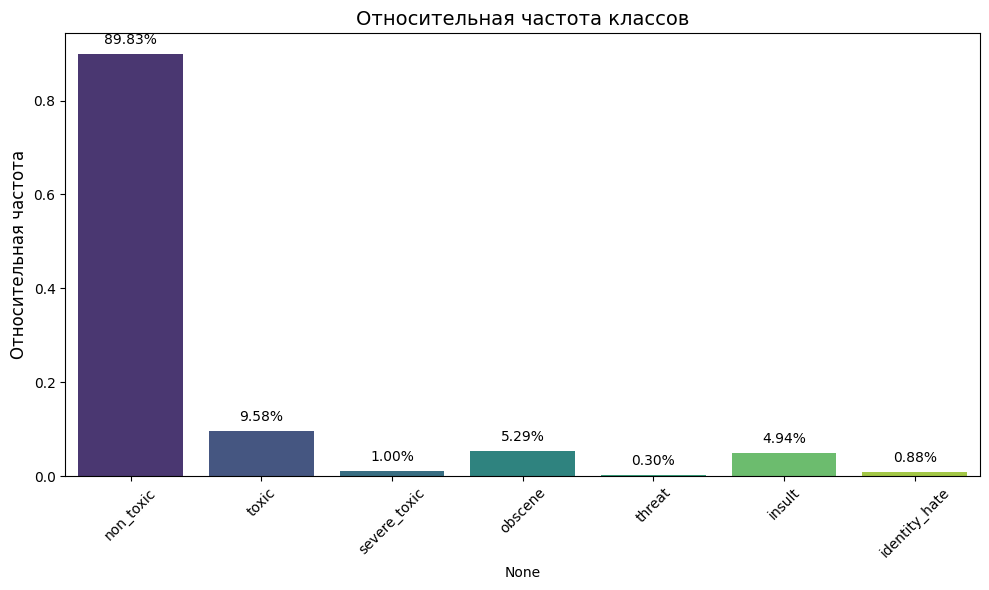

In [4]:
# Определяем целевые переменные
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Создаем бинарный признак для безопасных комментариев
df['non_toxic'] = (df[target_cols].sum(axis=1) == 0).astype(int)

# Список всех классов
all_classes = ['non_toxic'] + target_cols

# Вычисляем доли и абсолютные частоты
frequencies = df[all_classes].mean()
counts = df[all_classes].sum()

# Вывод сводной таблицы
summary_df = pd.DataFrame({
    'Количество (шт.)': counts,
    'Доля от датасета': (frequencies * 100).round(2).astype(str) + '%'
})
print("=== Статистика по классам ===")
print(summary_df)

# Визуализация распределения
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=frequencies.index, 
    y=frequencies.values, 
    hue=frequencies.index, 
    palette='viridis', 
    legend=False
)

plt.title('Относительная частота классов', fontsize=14)
plt.ylabel('Относительная частота', fontsize=12)
plt.xticks(rotation=45)

# Аннотация процентов на графике
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2%}', 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        xytext=(0, 5), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# 3: Фильтрация иноязычных комментариев

In [6]:
# Фиксация seed для стабильности работы langdetect
DetectorFactory.seed = 42

def check_english_language(dataframe, column_name='comment_text'):
    """
    Фильтрует датасет, оставляя только англоязычные тексты.
    """
    def is_english(text):
        try:
            return detect(str(text)) == 'en'
        except:
            return False

    print(f"=== Анализ языка в колонке '{column_name}' ===")
    is_en_mask = dataframe[column_name].apply(is_english)
    
    en_count = is_en_mask.sum()
    total_count = len(dataframe)
    percent = (en_count / total_count) * 100
    
    print(f"Всего строк в датасете: {total_count}")
    print(f"Английских (True): {en_count} ({percent:.2f}%)")
    print(f"Иноязычных (False): {total_count - en_count} ({100 - percent:.2f}%)")
    
    return is_en_mask

# Применение фильтра и создание чистого датафрейма
is_english_mask = check_english_language(df, 'comment_text')
df_clean = df[is_english_mask].copy()
df_clean.reset_index(drop=True, inplace=True)

=== Анализ языка в колонке 'comment_text' ===
Всего строк в датасете: 159571
Английских (True): 155203 (97.26%)
Иноязычных (False): 4368 (2.74%)


# 4: Очистка текста и лемматизация

In [8]:
# Загрузка необходимых словарей NLTK
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Приведение к нижнему регистру, удаление спецсимволов и лемматизация.
    """
    text = str(text).lower()
    
    # Оставляем только английские буквы и одинарные пробелы
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Лемматизация разбитого на токены текста
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(lemmatized_words)

# Применение функции очистки
df_clean['cleaned_text'] = df_clean['comment_text'].apply(clean_text)
print(df_clean[['comment_text', 'cleaned_text']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kamlivas/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/kamlivas/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   
3  "\nMore\nI can't make any real suggestions on ...   
4  You, sir, are my hero. Any chance you remember...   

                                        cleaned_text  
0  explanation why the edits made under my userna...  
1  d aww he match this background colour i m seem...  
2  hey man i m really not trying to edit war it s...  
3  more i can t make any real suggestion on impro...  
4  you sir are my hero any chance you remember wh...  


# 5: Экспорт готовых данных

In [10]:
# Удаляем сырой текст, чтобы сэкономить место, оставляя только нужные колонки
cols_to_keep = ['id', 'cleaned_text'] + all_classes
df_final = df_clean[cols_to_keep]

# Сохранение очищенного датасета
df_final.to_csv('train_cleaned.csv', index=False)
print("Очищенный датасет успешно сохранен в 'train_cleaned.csv'")

Очищенный датасет успешно сохранен в 'train_cleaned.csv'
